In [ ]:
import os
import shutil
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Caminhos
entrada = '/content/drive/MyDrive/Datasets Treino/TreinoFinal'
saida = '/content/BID_Organizado_Final'

# Remove pasta antiga de saída, se existir
if os.path.exists(saida):
    shutil.rmtree(saida)
    print("🗑️ Pasta antiga /content/BID_Organizado_Final removida.")

# Criar pastas de destino
for classe in ['CNH', 'CPF', 'RG']:
    os.makedirs(os.path.join(saida, classe), exist_ok=True)

# Coletar todos os arquivos válidos
arquivos_para_copiar = []
for classe in ['CNH', 'CPF', 'RG']:
    pasta_origem = os.path.join(entrada, classe)
    pasta_destino = os.path.join(saida, classe)

    for arquivo in os.listdir(pasta_origem):
        if arquivo.endswith('_in.jpg'):
            origem = os.path.join(pasta_origem, arquivo)
            destino = os.path.join(pasta_destino, arquivo)
            arquivos_para_copiar.append((origem, destino))

# Função de cópia individual
def copiar(origem_destino):
    origem, destino = origem_destino
    shutil.copy(origem, destino)

# Cópia paralela com barra de progresso
print(f" Copiando {len(arquivos_para_copiar)} imagens com threads...")
with ThreadPoolExecutor(max_workers=16) as executor:
    list(tqdm(executor.map(copiar, arquivos_para_copiar), total=len(arquivos_para_copiar)))

print("Cópia finalizada para /content/BID_Organizado_Final.")

🔁 Copiando 25000 imagens com threads...


100%|██████████| 25000/25000 [17:01<00:00, 24.47it/s]

✅ Cópia finalizada para /content/BID_Organizado_Final.


Found 20000 images belonging to 3 classes.
Found 5000 images belonging to 3 classes.
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 353ms/step - accuracy: 0.7340 - loss: 0.7330 - val_accuracy: 0.9516 - val_loss: 0.1320
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 350ms/step - accuracy: 0.9503 - loss: 0.1396 - val_accuracy: 0.9560 - val_loss: 0.1132
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 351ms/step - accuracy: 0.9772 - loss: 0.0692 - val_accuracy: 0.9530 - val_loss: 0.1234
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 352ms/step - accuracy: 0.9859 - loss: 0.0471 - val_accuracy: 0.9810 - val_loss: 0.0513
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 349ms/step - accuracy: 0.9829 - loss: 0.0522 - val_accuracy: 0.9892 - val_loss: 0.0308
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 349ms/step - accuracy: 0.9902 - loss: 0.0331 - val_accuracy: 0.9842 - val_loss: 0.0508
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 351ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.9958 - val_loss

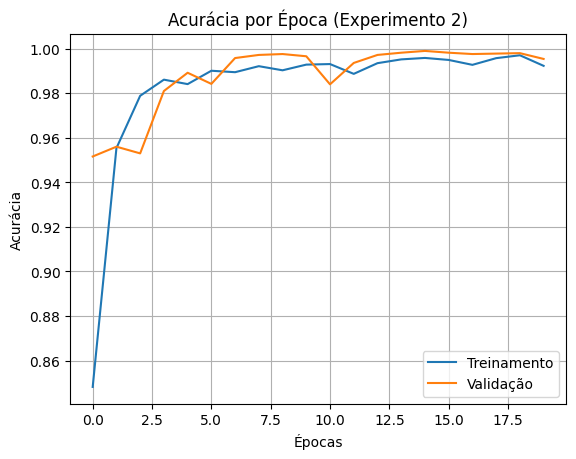

✅ Modelo salvo como .keras e .h5 em /content/drive/MyDrive/CNN_Rede_Profunda/1 CNN Profunda padrão/


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Função para converter para escala de cinza (mantendo 3 canais)
def to_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)  # mantém formato (128, 128, 3)
    return gray

# Gerador de imagens com augmentations e escala de cinza
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    brightness_range=[0.7, 1.3],
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    preprocessing_function=to_grayscale
)

# Dados de treino e validação
train = datagen.flow_from_directory(
    '/content/BID_Organizado_Final',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val = datagen.flow_from_directory(
    '/content/BID_Organizado_Final',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Modelo CNN com Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(3, activation='softmax')
])

# Compilação
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# EarlyStopping
earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Treinamento com callbacks
history = model.fit(
    train,
    validation_data=val,
    epochs=30,
    callbacks=[earlystop_cb]
)

# Curva de acurácia
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title("Acurácia por Época (Experimento 2)")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid()
plt.show()

# Salvar modelo nos dois formatos
model.save('/content/drive/MyDrive/CNN_Rede_Profunda/1 CNN Profunda padrão/early_rede_profunda_padrao.keras')
model.save('/content/drive/MyDrive/CNN_Rede_Profunda/1 CNN Profunda padrão/early_rede_profunda_padrao.h5')
print(" Modelo salvo como .keras e .h5 em /content/drive/MyDrive/CNN_Rede_Profunda/1 CNN Profunda padrão/")


Found 3800 images belonging to 3 classes.

🔍 Carregando imagens de teste do TesteFinal_BID:


📦 Batches:   0%|          | 0/119 [00:00<?, ?it/s]


✅ Avaliação - TesteFinal_BID
🔸 Acurácia:   1.0000
🔸 F1-score:   1.0000


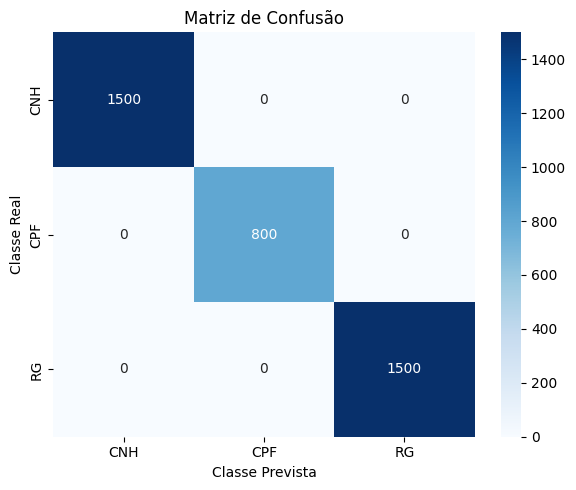

In [1]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Função de pré-processamento (caso tenha sido usada no treino)
def to_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

# Função principal de avaliação
def avaliar_conjunto(data_dir, nome_dataset, model):
    datagen_test = ImageDataGenerator(
        rescale=1./255,
        preprocessing_function=to_grayscale  # use None se não usou escala de cinza
    )

    test_gen = datagen_test.flow_from_directory(
        data_dir,
        target_size=(128, 128),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    X_test, Y_test = [], []
    print(f"\n Carregando imagens de teste do {nome_dataset}:")
    for _ in tqdm(range(len(test_gen)), desc="📦 Batches"):
        x, y = next(test_gen)
        X_test.append(x)
        Y_test.append(y)

    X_test = np.concatenate(X_test)
    Y_test = np.concatenate(Y_test)

    # Predição
    y_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    # Cálculo das métricas finais
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    conf_mat = confusion_matrix(y_true, y_pred)

    # Resultados
    print(f"\n Avaliação - {nome_dataset}")
    print(f" Acurácia:   {acc:.4f}")
    print(f" F1-score:   {f1:.4f}")

    # 🔷 Matriz de Confusão
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=test_gen.class_indices.keys(),
                yticklabels=test_gen.class_indices.keys())
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title(f"Matriz de Confusão")
    plt.tight_layout()
    plt.show()

# Caminhos para os conjuntos de teste
path_bid = '/content/drive/MyDrive/Datasets Teste/TesteFinal_BID'

# Carregamento do modelo treinado
model = load_model('/content/drive/MyDrive/CNN_Rede_Profunda/1 CNN Profunda padrão/rede_profunda_padrao.h5')

# Avaliação dos conjuntos
avaliar_conjunto(path_bid, "TesteFinal_BID", model)